# 02 — TSI Analysis & Experiments
## Sensibilidad Temporal de Descriptores de Audio Artesanales

Este notebook carga los features pre-extraídos (del notebook `01_feature_extraction.ipynb`) y ejecuta:
1. Cómputo del Índice de Sensibilidad Temporal (TSI)
2. Comparación de 4 estrategias de fusión
3. Experimento multi-label (MTAT)
4. Análisis de importancia (Permutation Importance)
5. Validación estadística (Wilcoxon, Cliff's delta, Spearman)
6. Visualizaciones y tablas LaTeX para el paper

**Requisito:** Ejecutar primero `01_feature_extraction.ipynb` para generar los `.npy` en Drive.

**Ejecución:** Google Colab Pro (GPU recomendada para MLP)

## 0. Setup & Load Cached Features

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install dependencies
!pip install -q librosa scikit-learn torch torchaudio tqdm seaborn xgboost

# cuML: GPU-accelerated Random Forest (NVIDIA CUDA only — A100, T4, etc.)
# Falls back to sklearn RF automatically if not available.
!pip install -q cuml-cu12 --extra-index-url=https://pypi.nvidia.com 2>/dev/null || echo "cuML not available — sklearn RF will be used"

# Clone the repo to get the src/ modules
import os
REPO_URL = "https://github.com/Gabrieleeh32159/my_paper.git"
REPO_DIR = "/content/my_paper"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull

Cloning into '/content/my_paper'...
remote: Enumerating objects: 288, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 288 (delta 31), reused 49 (delta 28), pack-reused 234 (from 1)
Receiving objects: 100% (288/288), 22.20 MiB | 27.49 MiB/s, done.
Resolving deltas: 100% (167/167), done.


In [3]:
import os
import sys
import numpy as np
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# === CONFIGURATION ===
REPO_DIR = Path('/content/my_paper')

# Google Drive paths
DRIVE_ROOT = Path('/content/drive/MyDrive/tsi_experiments')
DATA_ROOT = DRIVE_ROOT / 'data'
FEATURES_ROOT = DRIVE_ROOT / 'features'
RESULTS_ROOT = DRIVE_ROOT / 'results'

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

# Add repo's experiments/ to path
sys.path.insert(0, str(REPO_DIR / 'experiments'))

# Dataset paths (needed for metadata: n_classes, class_names, task_type)
DATASET_PATHS = {
    'gtzan': DATA_ROOT / 'gtzan',
    'fma_small': DATA_ROOT,
    'mtat': DATA_ROOT / 'magnatagatune',
    'irmas': DATA_ROOT / 'irmas',
}

SEED = 42
np.random.seed(SEED)

print(f"Features source: {FEATURES_ROOT}")
print(f"Results output:  {RESULTS_ROOT}")

Features source: /content/drive/MyDrive/tsi_experiments/features
Results output:  /content/drive/MyDrive/tsi_experiments/results


In [4]:
%cd {REPO_DIR}/experiments

from src.features import FEATURE_DIMS, SCALES, TRACK_DIM
from src.data_loader import get_dataset
from src.fusion import early_fusion
from src.classifiers import get_classifier, RFClassifier, XGBoostClassifier
from src.tsi import compute_tsi_cv_full, tsi_consistency
from src.evaluation import run_full_evaluation
from src.importance import aggregate_importance_by_descriptor_and_scale
from src.stats import spearman_with_bootstrap_ci, run_pairwise_comparisons

from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns

print("All modules loaded.")
print(f"Feature dimensions per frame: {sum(FEATURE_DIMS.values())} ({FEATURE_DIMS})")
print(f"Track vector dim per scale: {TRACK_DIM}")
print(f"Temporal scales: {SCALES}")

/content/my_paper/experiments
All modules loaded.
Feature dimensions per frame: 48 ({'mfcc': 20, 'chroma': 12, 'spectral_centroid': 1, 'spectral_contrast': 7, 'spectral_rolloff': 1, 'zcr': 1, 'tonnetz': 6})
Track vector dim per scale: 192
Temporal scales: {'short': 0.2, 'medium': 2.0, 'long': 5.0}


In [5]:
# Load dataset metadata (for n_classes, class_names, task_type)
datasets = {}

for name, path in DATASET_PATHS.items():
    try:
        datasets[name] = get_dataset(name, str(path))
        print(f"{name}: {len(datasets[name])} items, {datasets[name].n_classes} classes, task={datasets[name].task_type}")
    except Exception as e:
        print(f"{name}: not available ({e})")

print(f"\nLoaded metadata for: {list(datasets.keys())}")

gtzan: 1000 items, 10 classes, task=multiclass
fma_small: 8000 items, 8 classes, task=multiclass
mtat: 25863 items, 50 classes, task=multilabel
irmas: 7512 items, 11 classes, task=multiclass

Loaded metadata for: ['gtzan', 'fma_small', 'mtat', 'irmas']


In [6]:
# Load pre-extracted features from Drive
all_features = {}
all_labels = {}
all_splits = {}

for name in datasets.keys():
    short_path = FEATURES_ROOT / f"{name}_short.npy"
    if not short_path.exists():
        print(f"{name}: features not found in {FEATURES_ROOT}, skipping.")
        print(f"  Run 01_feature_extraction.ipynb first.")
        continue

    all_features[name] = {
        'short':  np.load(FEATURES_ROOT / f"{name}_short.npy"),
        'medium': np.load(FEATURES_ROOT / f"{name}_medium.npy"),
        'long':   np.load(FEATURES_ROOT / f"{name}_long.npy"),
    }
    raw_labels = np.load(FEATURES_ROOT / f"{name}_labels.npy", allow_pickle=True)
    all_splits[name] = np.load(FEATURES_ROOT / f"{name}_splits.npy", allow_pickle=True)

    # Fix: labels were saved as dtype=object, which sklearn rejects.
    # Cast to proper numeric types.
    if datasets[name].task_type == 'multilabel':
        all_labels[name] = np.stack(raw_labels).astype(np.float32)
    else:
        all_labels[name] = raw_labels.astype(int)

    n = all_features[name]['short'].shape[0]
    d = all_features[name]['short'].shape[1]
    print(f"{name}: {n} tracks x {d}-d x 3 scales (labels dtype={all_labels[name].dtype})")

print(f"\n=== Features loaded for: {list(all_features.keys())} ===")

gtzan: 999 tracks x 192-d x 3 scales (labels dtype=int64)
fma_small: 7996 tracks x 192-d x 3 scales (labels dtype=int64)
mtat: 25700 tracks x 192-d x 3 scales (labels dtype=float32)
irmas: 3756 tracks x 192-d x 3 scales (labels dtype=int64)

=== Features loaded for: ['gtzan', 'fma_small', 'mtat', 'irmas'] ===


## 1. TSI Computation

For each descriptor, train a classifier using ONLY that descriptor at each scale.

$$TSI(f) = \frac{\max_k Acc(f,k) - \min_k Acc(f,k)}{Acc_{chance}}$$

In [7]:
N_FOLDS = 5

def get_cv_folds(labels, n_folds=N_FOLDS, seed=SEED):
    """Generate StratifiedKFold splits for any dataset."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    folds = list(skf.split(np.zeros(len(labels)), labels))
    return folds

# Pre-generate folds for all multiclass datasets
all_folds = {}
for ds_name in all_features.keys():
    if datasets[ds_name].task_type == 'multilabel':
        continue
    all_folds[ds_name] = get_cv_folds(all_labels[ds_name])
    print(f"{ds_name}: {N_FOLDS}-fold CV, "
          f"fold 0 → train={len(all_folds[ds_name][0][0])}, test={len(all_folds[ds_name][0][1])}")

gtzan: 5-fold CV, fold 0 → train=799, test=200
fma_small: 5-fold CV, fold 0 → train=6396, test=1600
irmas: 5-fold CV, fold 0 → train=3004, test=752


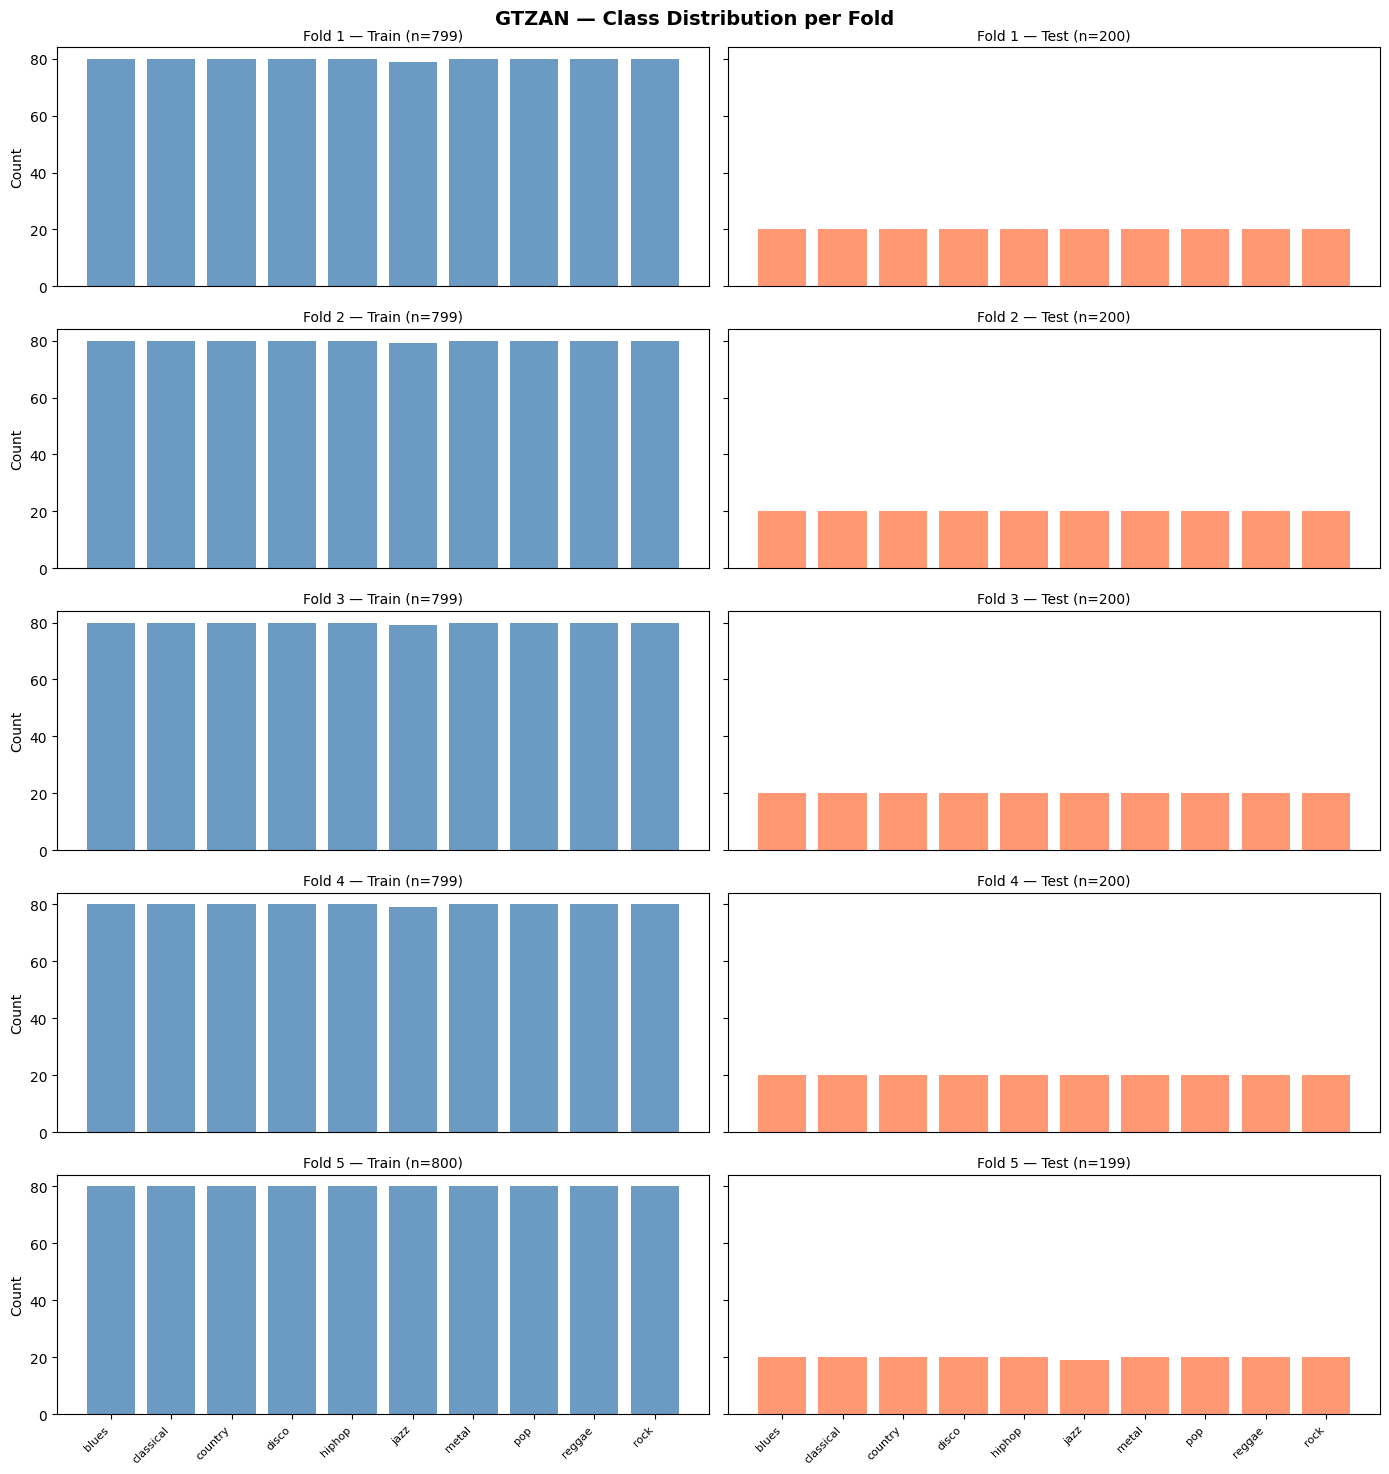

Saved: gtzan_fold_distributions.png


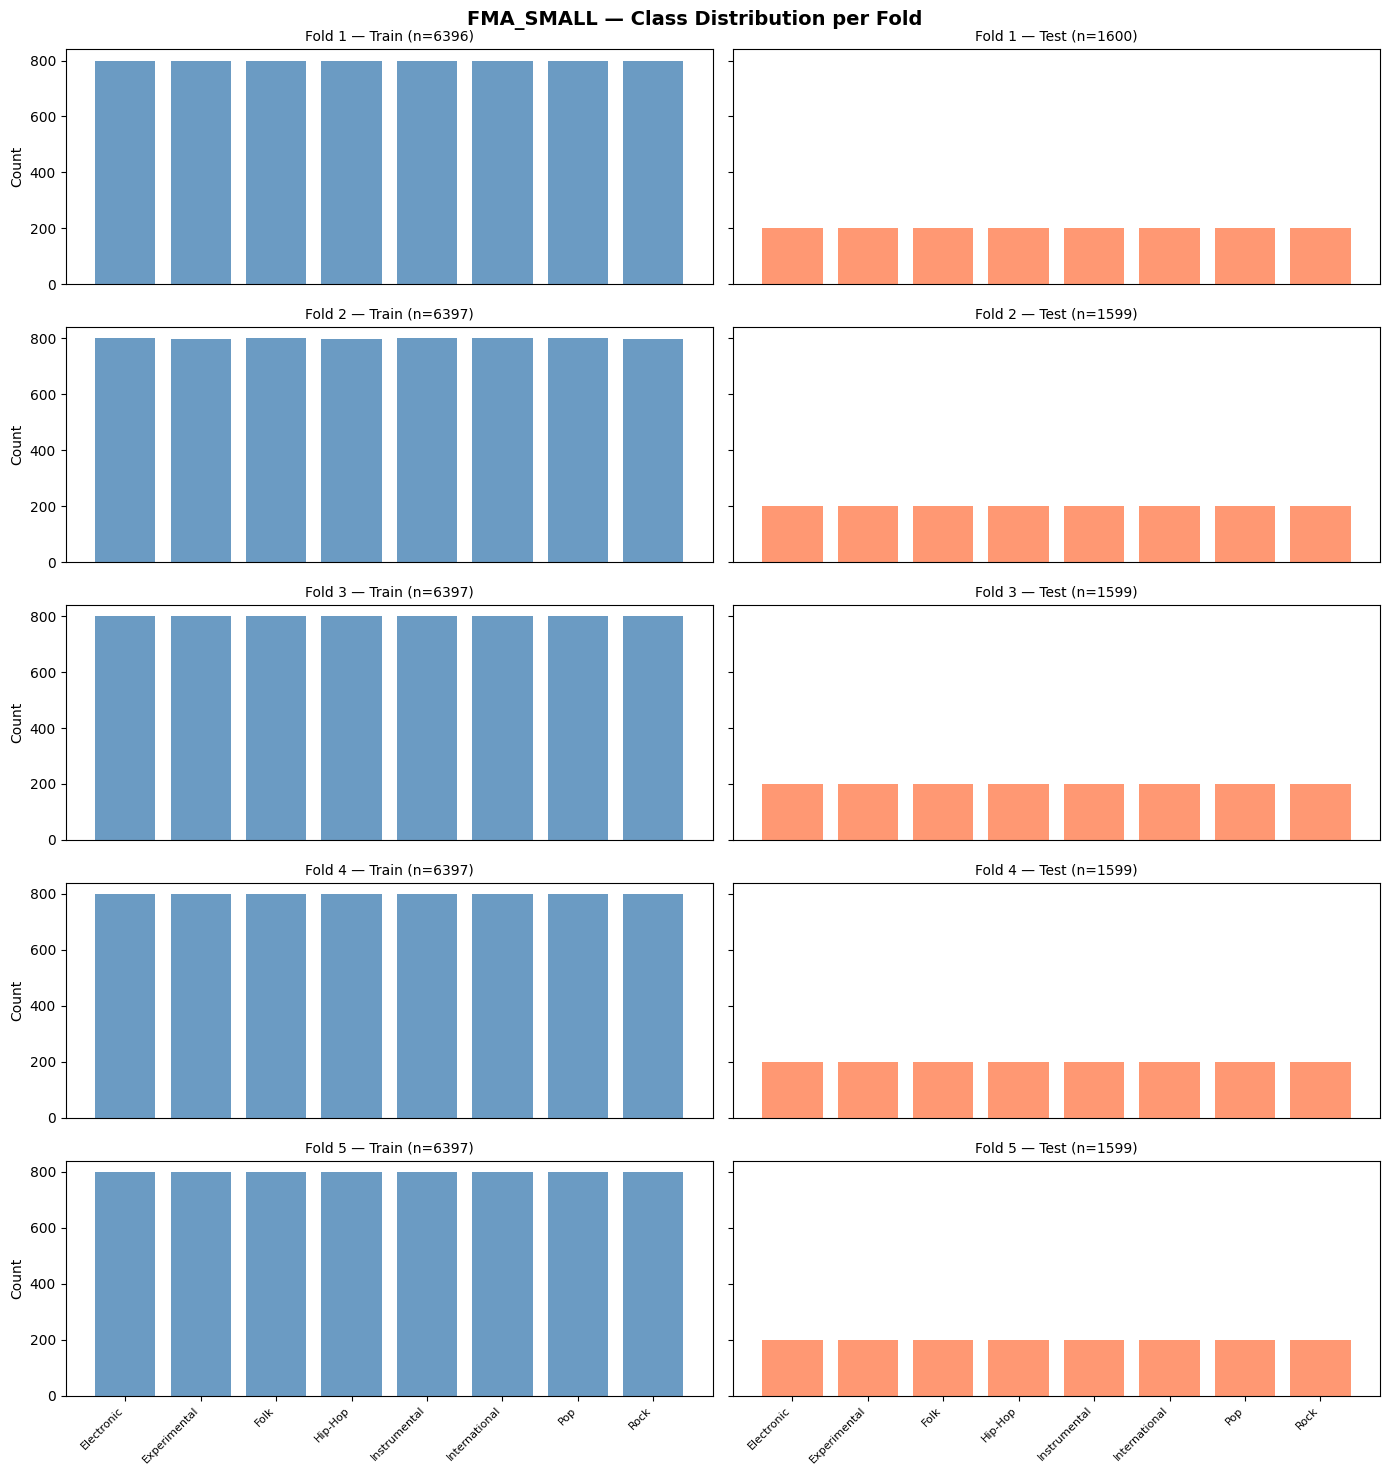

Saved: fma_small_fold_distributions.png


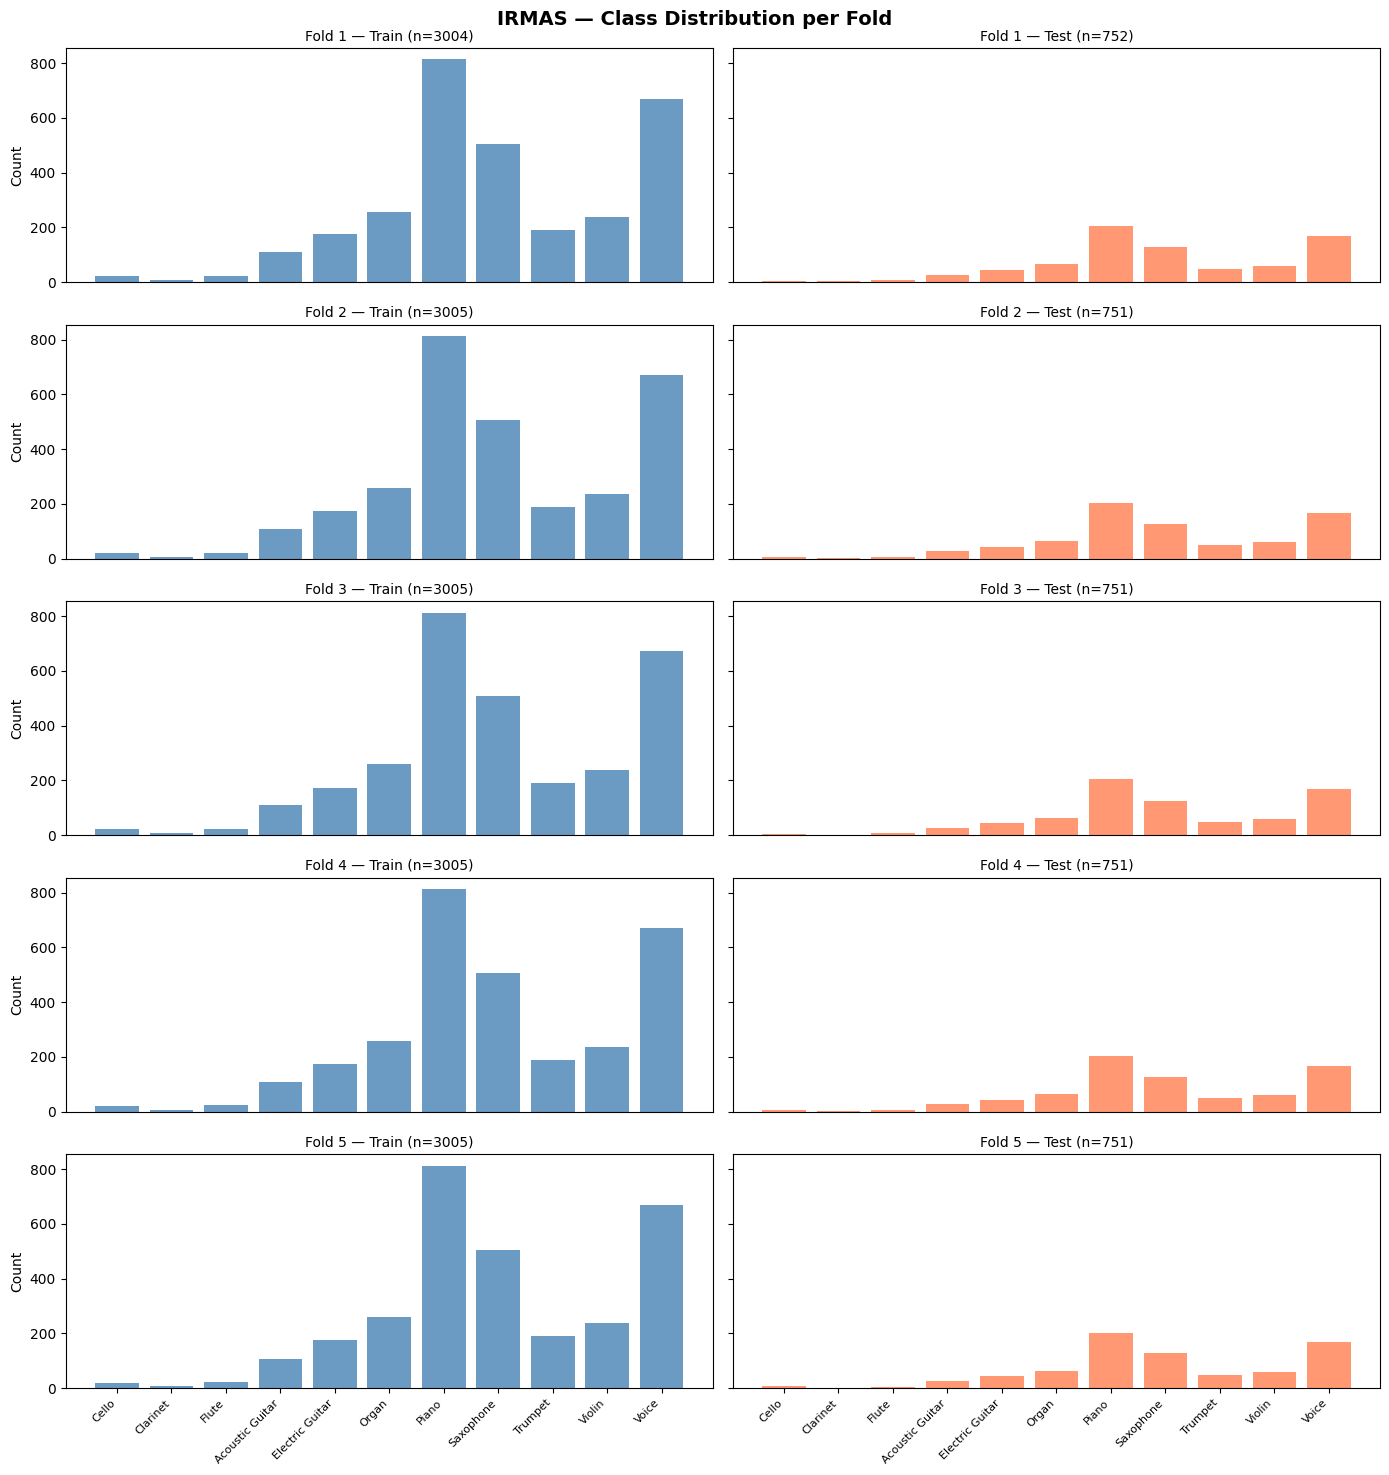

Saved: irmas_fold_distributions.png


In [8]:
# Visualize class distribution in train/test for each fold
for ds_name, folds in all_folds.items():
    labels = all_labels[ds_name]
    class_names = datasets[ds_name].class_names
    n_classes = datasets[ds_name].n_classes
    n_folds = len(folds)

    fig, axes = plt.subplots(n_folds, 2, figsize=(14, 3 * n_folds), sharey=True)
    fig.suptitle(f'{ds_name.upper()} — Class Distribution per Fold', fontsize=14, fontweight='bold')

    for fold_idx, (train_idx, test_idx) in enumerate(folds):
        y_train = labels[train_idx]
        y_test = labels[test_idx]

        # Count per class
        train_counts = np.bincount(y_train, minlength=n_classes)
        test_counts = np.bincount(y_test, minlength=n_classes)

        ax_train = axes[fold_idx, 0]
        ax_test = axes[fold_idx, 1]

        ax_train.bar(range(n_classes), train_counts, color='steelblue', alpha=0.8)
        ax_train.set_title(f'Fold {fold_idx+1} — Train (n={len(train_idx)})', fontsize=10)
        ax_train.set_ylabel('Count')

        ax_test.bar(range(n_classes), test_counts, color='coral', alpha=0.8)
        ax_test.set_title(f'Fold {fold_idx+1} — Test (n={len(test_idx)})', fontsize=10)

        if fold_idx == n_folds - 1:
            ax_train.set_xticks(range(n_classes))
            ax_train.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
            ax_test.set_xticks(range(n_classes))
            ax_test.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
        else:
            ax_train.set_xticks([])
            ax_test.set_xticks([])

    plt.tight_layout()
    plt.savefig(RESULTS_ROOT / f'{ds_name}_fold_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {ds_name}_fold_distributions.png")

## Dataset & Feature Sanity Checks

Verify that features, labels, and splits are consistent and correctly aligned.

In [9]:
# === SANITY CHECKS ===
print("=" * 70)
print("SANITY CHECKS")
print("=" * 70)

for ds_name in all_features.keys():
    if datasets[ds_name].task_type == 'multilabel':
        continue

    labels = all_labels[ds_name]
    feats = all_features[ds_name]
    n = len(labels)

    print(f"\n--- {ds_name} ---")

    # 1. Feature shape consistency across scales
    for scale in ['short', 'medium', 'long']:
        assert feats[scale].shape[0] == n, (
            f"  FAIL: {scale} has {feats[scale].shape[0]} rows, expected {n}"
        )
        assert feats[scale].shape[1] == TRACK_DIM, (
            f"  FAIL: {scale} dim={feats[scale].shape[1]}, expected {TRACK_DIM}"
        )
    print(f"  [OK] Feature shapes: {n} x {TRACK_DIM} x 3 scales")

    # 2. Labels dtype and range
    assert labels.dtype in (np.int32, np.int64, int), (
        f"  FAIL: labels dtype={labels.dtype}, expected int"
    )
    unique_labels = np.unique(labels)
    assert len(unique_labels) == datasets[ds_name].n_classes, (
        f"  FAIL: {len(unique_labels)} unique labels, expected {datasets[ds_name].n_classes}"
    )
    print(f"  [OK] Labels: dtype={labels.dtype}, classes={list(unique_labels)}")

    # 3. No NaN/Inf in features
    for scale in ['short', 'medium', 'long']:
        has_nan = np.isnan(feats[scale]).any()
        has_inf = np.isinf(feats[scale]).any()
        assert not has_nan, f"  FAIL: NaN in {scale}"
        assert not has_inf, f"  FAIL: Inf in {scale}"
    print(f"  [OK] No NaN/Inf in features")

    # 4. CV fold correctness: no overlap, full coverage
    if ds_name in all_folds:
        for fold_idx, (train_idx, test_idx) in enumerate(all_folds[ds_name]):
            overlap = np.intersect1d(train_idx, test_idx)
            assert len(overlap) == 0, (
                f"  FAIL: Fold {fold_idx} has {len(overlap)} overlapping indices!"
            )
            assert len(train_idx) + len(test_idx) == n, (
                f"  FAIL: Fold {fold_idx} covers {len(train_idx)+len(test_idx)}/{n} samples"
            )
        print(f"  [OK] {len(all_folds[ds_name])} folds: no overlap, full coverage")

    # 5. Class balance check in folds
    if ds_name in all_folds:
        for fold_idx, (train_idx, test_idx) in enumerate(all_folds[ds_name]):
            train_dist = np.bincount(labels[train_idx], minlength=datasets[ds_name].n_classes)
            test_dist = np.bincount(labels[test_idx], minlength=datasets[ds_name].n_classes)
            train_pct = train_dist / train_dist.sum()
            test_pct = test_dist / test_dist.sum()
            max_diff = np.max(np.abs(train_pct - test_pct))
            if max_diff > 0.05:
                print(f"  [WARN] Fold {fold_idx}: max class proportion diff = {max_diff:.3f}")
        print(f"  [OK] Class proportions balanced across folds (StratifiedKFold)")

print("\n" + "=" * 70)
print("ALL CHECKS PASSED")
print("=" * 70)

SANITY CHECKS

--- gtzan ---
  [OK] Feature shapes: 999 x 192 x 3 scales
  [OK] Labels: dtype=int64, classes=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
  [OK] No NaN/Inf in features
  [OK] 5 folds: no overlap, full coverage
  [OK] Class proportions balanced across folds (StratifiedKFold)

--- fma_small ---
  [OK] Feature shapes: 7996 x 192 x 3 scales
  [OK] Labels: dtype=int64, classes=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
  [OK] No NaN/Inf in features
  [OK] 5 folds: no overlap, full coverage
  [OK] Class proportions balanced across folds (StratifiedKFold)

--- irmas ---
  [OK] Feature shapes: 3756 x 192 x 3 scales
  [OK] Labels: dtype=int64, classes=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  [OK] No NaN/Inf in features
  [OK] 5 f

In [10]:
# Compute TSI for all available datasets with XGBoost (StratifiedKFold CV)
# Uses normalized information gain G(f,k) = 1 - L(f,k)/L_chance instead of accuracy.
# compute_tsi_cv_full returns mean TSI, bootstrap CI, per-scale IG, and
# a per-descriptor Wilcoxon test (best vs. worst scale).
tsi_results = {}

for ds_name in all_folds.keys():
    n_classes = datasets[ds_name].n_classes
    folds = all_folds[ds_name]
    features = all_features[ds_name]
    labels = all_labels[ds_name]

    print(f"\n{'='*60}")
    print(f"Computing TSI for {ds_name} (n_classes={n_classes}, {N_FOLDS}-fold CV)")
    print(f"{'='*60}")

    result = compute_tsi_cv_full(
        features=features,
        labels=labels,
        n_classes=n_classes,
        folds=folds,
        classifier_name='xgb',
        task_type='multiclass',
        n_bootstrap=1000,
    )
    tsi_results[ds_name] = result

    # Print results table
    print(f"\n  {'Descriptor':<20} {'TSI':>12} {'95% CI':>20} {'Sig':>5} {'Short':>8} {'Medium':>8} {'Long':>8} {'Opt':>7}")
    print(f"  {'-'*93}")
    for desc in FEATURE_DIMS.keys():
        tsi_val = result['tsi_scores'][desc]
        tsi_std = result['tsi_std'][desc]
        lo, hi  = result['tsi_ci'][desc]
        sig     = '✓' if result['scale_significant'][desc] else '—'
        g_s     = result['info_gain_matrix'][desc]['short']
        g_m     = result['info_gain_matrix'][desc]['medium']
        g_l     = result['info_gain_matrix'][desc]['long']
        opt     = result['optimal_scales'][desc]
        ci_str  = f"[{lo:.3f}, {hi:.3f}]"
        print(f"  {desc:<20} {tsi_val:>6.3f}±{tsi_std:.3f} {ci_str:>20} {sig:>5} "
              f"{g_s:>8.4f} {g_m:>8.4f} {g_l:>8.4f} {opt:>7}")

# Save TSI results
with open(RESULTS_ROOT / 'tsi_results.json', 'w') as f:
    json.dump(tsi_results, f, indent=2, default=float)
print(f"\nTSI results saved to {RESULTS_ROOT / 'tsi_results.json'}")


Computing TSI for gtzan (n_classes=10, 5-fold CV)

  Descriptor                    TSI               95% CI   Sig    Short   Medium     Long     Opt
  ---------------------------------------------------------------------------------------------
  mfcc                  0.015±0.004       [0.008, 0.022]     —   0.5250   0.5076   0.4894   short
  chroma                0.014±0.003       [0.010, 0.021]     —   0.3143   0.2822   0.2860   short
  spectral_centroid     0.017±0.002       [0.014, 0.021]     —   0.2162   0.1879   0.1760   short
  spectral_contrast     0.015±0.002       [0.010, 0.019]     —   0.4218   0.3891   0.3907   short
  spectral_rolloff      0.014±0.001       [0.013, 0.017]     —   0.2086   0.1911   0.1747   short
  zcr                   0.003±0.002       [0.001, 0.008]     —   0.1458   0.1374   0.1402   short
  tonnetz               0.047±0.005       [0.037, 0.056]     —   0.3110   0.2264   0.2019   short

Computing TSI for fma_small (n_classes=8, 5-fold CV)

  Descriptor 

## 2. Fusion Strategy Comparison

Compare 6 strategies: single-scale (short/medium/long), early fusion, late fusion, TSI-weighted fusion.

In [11]:
def run_experiment_cv(ds_name, features, labels, folds, dataset, tsi_info, classifier_name='rf'):
    """
    Run full experiment with StratifiedKFold CV.
    Returns per-strategy: mean ± std of accuracy and F1 across folds.
    """
    n_classes = dataset.n_classes
    strategies = ['short', 'medium', 'long', 'early', 'late', 'tsi_weighted']

    # Collect per-fold metrics
    fold_metrics = {s: {'accuracy': [], 'f1_macro': []} for s in strategies}

    for fold_idx, (train_idx, test_idx) in enumerate(folds):
        for strategy in strategies:
            if strategy in ('short', 'medium', 'long'):
                input_dim = TRACK_DIM
            elif strategy == 'early':
                input_dim = TRACK_DIM * 3
            elif strategy == 'tsi_weighted':
                input_dim = sum(4 * FEATURE_DIMS[d] for d in FEATURE_DIMS.keys())
            else:  # late
                input_dim = TRACK_DIM

            clf = get_classifier(classifier_name, input_dim=input_dim, n_classes=n_classes)

            fusion_params = None
            if strategy == 'tsi_weighted' and tsi_info:
                fusion_params = {
                    'tsi_scores': tsi_info['tsi_scores'],
                    'optimal_scales': tsi_info['optimal_scales'],
                }

            result = run_full_evaluation(
                features=features,
                labels=labels,
                classifier=clf,
                train_idx=train_idx,
                test_idx=test_idx,
                strategy=strategy,
                task_type='multiclass',
                class_names=dataset.class_names,
                fusion_params=fusion_params,
            )
            fold_metrics[strategy]['accuracy'].append(result['accuracy'])
            fold_metrics[strategy]['f1_macro'].append(result['f1_macro'])

    # Aggregate
    results = {}
    for strategy in strategies:
        accs = np.array(fold_metrics[strategy]['accuracy'])
        f1s = np.array(fold_metrics[strategy]['f1_macro'])
        results[strategy] = {
            'accuracy_mean': float(np.mean(accs)),
            'accuracy_std': float(np.std(accs)),
            'f1_macro_mean': float(np.mean(f1s)),
            'f1_macro_std': float(np.std(f1s)),
            'accuracy_per_fold': accs.tolist(),
            'f1_per_fold': f1s.tolist(),
        }

    return results

In [12]:
# Run experiments: all datasets x all classifiers x StratifiedKFold CV
all_experiment_results = {}
CLASSIFIERS = ['rf', 'xgb', 'svm', 'mlp']

for ds_name in all_folds.keys():
    print(f"\n{'='*70}")
    print(f"DATASET: {ds_name} ({datasets[ds_name].n_classes} classes, "
          f"{all_features[ds_name]['short'].shape[0]} tracks, {N_FOLDS}-fold CV)")
    print(f"{'='*70}")

    all_experiment_results[ds_name] = {}
    tsi_info = tsi_results.get(ds_name)

    for clf_name in CLASSIFIERS:
        print(f"\n  Classifier: {clf_name.upper()}")
        print(f"  {'-'*60}")

        results = run_experiment_cv(
            ds_name=ds_name,
            features=all_features[ds_name],
            labels=all_labels[ds_name],
            folds=all_folds[ds_name],
            dataset=datasets[ds_name],
            tsi_info=tsi_info,
            classifier_name=clf_name,
        )
        all_experiment_results[ds_name][clf_name] = results

        # Print summary table
        print(f"    {'Strategy':<15} {'Accuracy':>18} {'F1-macro':>18}")
        print(f"    {'-'*53}")
        for strategy, metrics in results.items():
            acc = f"{metrics['accuracy_mean']:.4f}±{metrics['accuracy_std']:.4f}"
            f1 = f"{metrics['f1_macro_mean']:.4f}±{metrics['f1_macro_std']:.4f}"
            print(f"    {strategy:<15} {acc:>18} {f1:>18}")

# Save results
with open(RESULTS_ROOT / 'experiment_results.json', 'w') as f:
    json.dump(all_experiment_results, f, indent=2)
print(f"\nResults saved to {RESULTS_ROOT / 'experiment_results.json'}")


DATASET: gtzan (10 classes, 999 tracks, 5-fold CV)

  Classifier: RF
  ------------------------------------------------------------


ValueError: _CuMLRFWrapper should either be a classifier to be used with response_method=['decision_function', 'predict_proba'] or the response_method should be 'predict'. Got a regressor with response_method=['decision_function', 'predict_proba'] instead.

## 2b. MTAT (Multi-label) Experiment

In [ ]:
# MTAT experiment (if available)
if 'mtat' in all_features:
    print("\n" + "="*70)
    print("DATASET: MTAT (50 tags, multilabel)")
    print("="*70)

    features_mtat = all_features['mtat']
    labels_mtat = all_labels['mtat']
    splits_mtat = all_splits['mtat']

    train_idx = np.where(splits_mtat == 'train')[0]
    test_idx = np.where(splits_mtat == 'test')[0]

    # Compute class weights for MLP (inverse frequency)
    pos_counts = labels_mtat[train_idx].sum(axis=0)
    neg_counts = len(train_idx) - pos_counts
    class_weights = neg_counts / (pos_counts + 1e-6)

    mtat_results = {}
    strategies = ['short', 'medium', 'long', 'early', 'late']

    for strategy in strategies:
        print(f"  Strategy: {strategy}...", end=' ')

        if strategy in ('short', 'medium', 'long'):
            input_dim = TRACK_DIM  # 192
        else:
            input_dim = TRACK_DIM * 3  # 576

        clf = get_classifier(
            'mlp', input_dim=input_dim, n_classes=50,
            task_type='multilabel', class_weights=class_weights
        )

        result = run_full_evaluation(
            features=features_mtat,
            labels=labels_mtat,
            classifier=clf,
            train_idx=train_idx,
            test_idx=test_idx,
            strategy=strategy,
            task_type='multilabel',
            class_names=datasets['mtat'].class_names,
        )
        mtat_results[strategy] = result
        print(f"mAP={result['mAP']:.4f}, AUC={result.get('roc_auc_macro', 'N/A')}")

    # Save MTAT results
    mtat_save = {s: {'mAP': r['mAP'], 'roc_auc_macro': r.get('roc_auc_macro')}
                 for s, r in mtat_results.items()}
    with open(RESULTS_ROOT / 'mtat_results.json', 'w') as f:
        json.dump(mtat_save, f, indent=2)
else:
    print("MTAT not available, skipping multilabel experiment.")

## 3. Feature Importance Analysis

In [ ]:
# Permutation Importance on early fusion with RF (using first fold)
from sklearn.inspection import permutation_importance as sklearn_pi

importance_results = {}

for ds_name in all_folds.keys():
    print(f"\nComputing Permutation Importance for {ds_name}...")

    features = all_features[ds_name]
    labels = all_labels[ds_name]
    train_idx, test_idx = all_folds[ds_name][0]  # Use first fold

    # Train RF on early fusion
    X_early = early_fusion(features)
    X_train, X_test = X_early[train_idx], X_early[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]

    rf = RFClassifier()
    rf.fit(X_train, y_train)

    # Permutation importance (using underlying sklearn model + scaler)
    X_test_scaled = rf.scaler.transform(X_test)
    pi_result = sklearn_pi(
        rf.model, X_test_scaled, y_test,
        n_repeats=30, scoring='f1_macro',
        random_state=SEED, n_jobs=-1
    )

    # Aggregate by descriptor x scale
    imp_matrix = aggregate_importance_by_descriptor_and_scale(
        pi_result.importances_mean, vector_dim=TRACK_DIM
    )

    importance_results[ds_name] = {
        'pi_mean': pi_result.importances_mean.tolist(),
        'pi_std': pi_result.importances_std.tolist(),
        'matrix': imp_matrix,
        'mdi': rf.feature_importances_.tolist(),
    }

    # Print importance matrix
    print(f"\n  Importance Matrix (PI, descriptor x scale):")
    print(f"  {'Descriptor':<20} {'Short':>10} {'Medium':>10} {'Long':>10}")
    print(f"  {'-'*52}")
    for desc in FEATURE_DIMS.keys():
        s = imp_matrix[desc]['short']
        m = imp_matrix[desc]['medium']
        l = imp_matrix[desc]['long']
        print(f"  {desc:<20} {s:>10.5f} {m:>10.5f} {l:>10.5f}")

# Save importance results
with open(RESULTS_ROOT / 'importance_results.json', 'w') as f:
    json.dump(importance_results, f, indent=2)
print(f"\nImportance results saved to {RESULTS_ROOT / 'importance_results.json'}")

## 4. Statistical Validation

In [ ]:
# Statistical tests: Wilcoxon + Cliff's delta (using per-fold accuracy as paired observations)
statistical_results = {}

for ds_name in all_experiment_results.keys():
    print(f"\n{'='*60}")
    print(f"Statistical Tests: {ds_name}")
    print(f"{'='*60}")

    clf_name = 'rf'  # Primary classifier
    strat_results = all_experiment_results[ds_name][clf_name]

    # Use per-fold accuracy as paired observations
    paired_scores = {}
    for strategy, metrics in strat_results.items():
        if 'accuracy_per_fold' in metrics:
            paired_scores[strategy] = np.array(metrics['accuracy_per_fold'])

    if len(paired_scores) < 2:
        print("  Not enough strategies for pairwise tests.")
        continue

    comparisons = run_pairwise_comparisons(paired_scores)
    statistical_results[ds_name] = comparisons

    print(f"\n  {'A vs B':<30} {'p-val':>8} {'Sig?':>6} {'Cliff d':>8} {'Effect':>10}")
    print(f"  {'-'*65}")
    for comp in comparisons:
        pair = f"{comp['strategy_a']} vs {comp['strategy_b']}"
        sig = 'Y' if comp['significant'] else 'N'
        print(f"  {pair:<30} {comp['p_value']:>8.5f} {sig:>6} {comp['cliffs_delta']:>8.3f} {comp['effect_magnitude']:>10}")

# Save statistical results
with open(RESULTS_ROOT / 'statistical_tests.json', 'w') as f:
    json.dump(statistical_results, f, indent=2, default=str)
print(f"\nStatistical results saved to {RESULTS_ROOT / 'statistical_tests.json'}")

In [ ]:
# TSI Consistency: Spearman correlation between datasets
print("\n=== TSI Consistency Across Datasets ===")

if len(tsi_results) >= 2:
    tsi_for_consistency = {
        ds_name: res['tsi_scores']
        for ds_name, res in tsi_results.items()
    }

    correlations = tsi_consistency(tsi_for_consistency)

    descriptors = list(FEATURE_DIMS.keys())

    for (cfg_a, cfg_b), rho in correlations.items():
        x = np.array([tsi_for_consistency[cfg_a][d] for d in descriptors])
        y = np.array([tsi_for_consistency[cfg_b][d] for d in descriptors])
        ci_result = spearman_with_bootstrap_ci(x, y)

        consistent = 'Y' if ci_result['consistent'] else 'N'
        print(f"  {cfg_a} vs {cfg_b}: rho={ci_result['rho']:.3f} "
              f"[{ci_result['ci_lower']:.3f}, {ci_result['ci_upper']:.3f}] "
              f"Consistent(>0.7): {consistent}")
else:
    print("  Need at least 2 datasets for consistency analysis.")

## 5. Visualization & Results for Paper

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set IEEE paper style
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.figsize': (7, 4),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

In [ ]:
# Figure 1: TSI Bar Chart per descriptor (with error bars from CV)
n_datasets = len(tsi_results)
fig, axes = plt.subplots(1, max(n_datasets, 1), figsize=(4*max(n_datasets, 1), 4), sharey=True)
if n_datasets == 1:
    axes = [axes]

for ax, (ds_name, res) in zip(axes, tsi_results.items()):
    descriptors = list(res['tsi_scores'].keys())
    tsi_vals = [res['tsi_scores'][d] for d in descriptors]
    tsi_errs = [res['tsi_std'][d] for d in descriptors]

    colors = ['#e74c3c' if v > 1.0 else '#3498db' if v > 0.5 else '#95a5a6' for v in tsi_vals]

    ax.barh(descriptors, tsi_vals, xerr=tsi_errs, color=colors, capsize=3)
    ax.set_xlabel('TSI')
    ax.set_title(ds_name.upper())
    ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='High sensitivity')
    ax.axvline(x=0.5, color='blue', linestyle='--', alpha=0.5, label='Moderate')

axes[0].set_ylabel('Descriptor')
plt.suptitle('Temporal Sensitivity Index (TSI) per Descriptor', fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_ROOT / 'fig_tsi_barchart.pdf')
plt.savefig(RESULTS_ROOT / 'fig_tsi_barchart.png')
plt.show()
print(f"Saved to {RESULTS_ROOT / 'fig_tsi_barchart.pdf'}")

In [ ]:
# Figure 2: 7x3 Information Gain Matrix (Heatmap)
for ds_name, res in tsi_results.items():
    ig_matrix = res['info_gain_matrix']
    ig_std    = res['info_gain_std']
    descriptors = list(FEATURE_DIMS.keys())
    scales = list(SCALES.keys())

    matrix = np.zeros((len(descriptors), len(scales)))
    annots = []
    for i, desc in enumerate(descriptors):
        row_annots = []
        for j, scale in enumerate(scales):
            g   = ig_matrix[desc][scale]
            std = ig_std[desc][scale]
            matrix[i, j] = g
            sig = '✓' if (scale == res['optimal_scales'][desc] and res['scale_significant'][desc]) else ''
            row_annots.append(f"{g:.3f}\n±{std:.3f}{sig}")
        annots.append(row_annots)

    fig, ax = plt.subplots(figsize=(5, 5))
    sns.heatmap(
        matrix, annot=annots, fmt='',
        xticklabels=['Short\n(200ms)', 'Medium\n(2s)', 'Long\n(5s)'],
        yticklabels=descriptors,
        cmap='YlOrRd', ax=ax,
        vmin=max(0, matrix.min() * 0.9),
        vmax=min(1, matrix.max() * 1.05),
    )
    ax.set_title(f'Information Gain G(f,k) — {ds_name.upper()}\n(✓ = optimal scale, Wilcoxon p<0.05)')
    ax.set_xlabel('Temporal Scale')
    ax.set_ylabel('Descriptor')
    plt.tight_layout()
    plt.savefig(RESULTS_ROOT / f'fig_sensitivity_matrix_{ds_name}.pdf')
    plt.savefig(RESULTS_ROOT / f'fig_sensitivity_matrix_{ds_name}.png')
    plt.show()
    print(f"Saved: fig_sensitivity_matrix_{ds_name}.pdf")

In [ ]:
# Figure 3: Strategy Comparison Bar Chart (mean ± std from CV)
for ds_name, clf_results in all_experiment_results.items():
    strategies = ['short', 'medium', 'long', 'early', 'late', 'tsi_weighted']
    classifiers = list(clf_results.keys())

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(strategies))
    width = 0.8 / len(classifiers)

    for i, clf_name in enumerate(classifiers):
        means = [clf_results[clf_name][s]['f1_macro_mean'] for s in strategies]
        stds = [clf_results[clf_name][s]['f1_macro_std'] for s in strategies]
        ax.bar(x + i*width, means, width, yerr=stds, label=clf_name.upper(),
               capsize=3, alpha=0.85)

    ax.set_xlabel('Fusion Strategy')
    ax.set_ylabel('F1 Macro')
    ax.set_title(f'Strategy Comparison -- {ds_name.upper()} ({N_FOLDS}-fold CV)')
    ax.set_xticks(x + width * (len(classifiers) - 1) / 2)
    ax.set_xticklabels(strategies, rotation=20)
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_ROOT / f'fig_strategy_comparison_{ds_name}.pdf')
    plt.savefig(RESULTS_ROOT / f'fig_strategy_comparison_{ds_name}.png')
    plt.show()

In [ ]:
# Figure 4: Importance Matrix Heatmap (early fusion, RF)
for ds_name, imp_res in importance_results.items():
    matrix = imp_res['matrix']
    descriptors = list(FEATURE_DIMS.keys())
    scales = list(SCALES.keys())

    mat_arr = np.zeros((len(descriptors), len(scales)))
    for i, desc in enumerate(descriptors):
        for j, scale in enumerate(scales):
            mat_arr[i, j] = matrix[desc][scale]

    fig, ax = plt.subplots(figsize=(5, 5))
    sns.heatmap(
        mat_arr, annot=True, fmt='.4f',
        xticklabels=['Short\n(200ms)', 'Medium\n(2s)', 'Long\n(5s)'],
        yticklabels=descriptors,
        cmap='viridis', ax=ax,
    )
    ax.set_title(f'Permutation Importance (descriptor x scale) -- {ds_name.upper()}')
    ax.set_xlabel('Temporal Scale')
    ax.set_ylabel('Descriptor')
    plt.tight_layout()
    plt.savefig(RESULTS_ROOT / f'fig_importance_matrix_{ds_name}.pdf')
    plt.savefig(RESULTS_ROOT / f'fig_importance_matrix_{ds_name}.png')
    plt.show()

## 6. LaTeX Tables for Paper

In [ ]:
# Generate LaTeX table: Main results (mean ± std)
def generate_results_latex(results, dataset_names):
    """Generate LaTeX table for paper with mean ± std from CV."""
    strategies = ['short', 'medium', 'long', 'early', 'late', 'tsi_weighted']
    strat_labels = ['Short (200ms)', 'Medium (2s)', 'Long (5s)',
                    'Early Fusion', 'Late Fusion', 'TSI-Weighted']

    lines = []
    lines.append(r'\begin{table}[htp]')
    lines.append(r'\centering')
    lines.append(r'\caption{Comparison of fusion strategies (F1 Macro $\pm$ std, ' + str(N_FOLDS) + '-fold CV).}')
    lines.append(r'\label{tab:results_main}')

    cols = 'l' + 'c' * len(dataset_names)
    lines.append(r'\begin{tabular}{@{}' + cols + r'@{}}')
    lines.append(r'\toprule')

    header = r'\textbf{Strategy}'
    for ds in dataset_names:
        header += f' & \\textbf{{{ds.upper()}}}'
    header += r' \\'
    lines.append(header)
    lines.append(r'\midrule')

    for clf_name in ['rf', 'xgb', 'svm', 'mlp']:
        lines.append(r'\addlinespace[3pt]')
        lines.append(r'\multicolumn{' + str(1 + len(dataset_names)) + r'}{l}{\textit{' + clf_name.upper() + r'}} \\')
        for strat, label in zip(strategies, strat_labels):
            row = f'\\quad {label}'
            for ds in dataset_names:
                if ds in results and clf_name in results[ds] and strat in results[ds][clf_name]:
                    m = results[ds][clf_name][strat]['f1_macro_mean']
                    s = results[ds][clf_name][strat]['f1_macro_std']
                    row += f' & ${m:.3f} \\pm {s:.3f}$'
                else:
                    row += ' & ---'
            row += r' \\'
            lines.append(row)

    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}')
    lines.append(r'\end{table}')

    return '\n'.join(lines)


latex_table = generate_results_latex(all_experiment_results, list(all_experiment_results.keys()))
print(latex_table)

with open(RESULTS_ROOT / 'table_results_main.tex', 'w') as f:
    f.write(latex_table)
print(f"\nSaved to {RESULTS_ROOT / 'table_results_main.tex'}")

In [ ]:
# Generate LaTeX table: TSI values (mean ± std)
def generate_tsi_latex(tsi_results):
    """Generate LaTeX table for TSI values with mean ± std from CV."""
    descriptors = list(FEATURE_DIMS.keys())
    datasets_available = list(tsi_results.keys())

    lines = []
    lines.append(r'\begin{table}[htp]')
    lines.append(r'\centering')
    lines.append(r'\caption{Temporal Sensitivity Index (TSI) per descriptor and dataset (' + str(N_FOLDS) + '-fold CV).}')
    lines.append(r'\label{tab:tsi_values}')

    cols = 'l' + 'c' * len(datasets_available)
    lines.append(r'\begin{tabular}{@{}' + cols + r'@{}}')
    lines.append(r'\toprule')

    header = r'\textbf{Descriptor}'
    for ds in datasets_available:
        header += f' & \\textbf{{{ds.upper()}}}'
    header += r' \\'
    lines.append(header)
    lines.append(r'\midrule')

    for desc in descriptors:
        row = desc.replace('_', ' ').title()
        for ds in datasets_available:
            m = tsi_results[ds]['tsi_scores'][desc]
            s = tsi_results[ds]['tsi_std'][desc]
            row += f' & ${m:.3f} \\pm {s:.3f}$'
        row += r' \\'
        lines.append(row)

    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}')
    lines.append(r'\end{table}')

    return '\n'.join(lines)


latex_tsi = generate_tsi_latex(tsi_results)
print(latex_tsi)

with open(RESULTS_ROOT / 'table_tsi_values.tex', 'w') as f:
    f.write(latex_tsi)
print(f"\nSaved to {RESULTS_ROOT / 'table_tsi_values.tex'}")

## 7. Summary & Final Report

In [ ]:
# Print comprehensive summary
print("\n" + "="*80)
print("EXPERIMENT SUMMARY")
print("="*80)

print(f"\nEvaluation: {N_FOLDS}-fold Stratified Cross-Validation")
print(f"TSI metric: Normalized Information Gain  G(f,k) = 1 - L(f,k) / L_chance")
print(f"Classifiers: {', '.join(c.upper() for c in CLASSIFIERS)}")

print("\n--- TSI Rankings (Higher = More temporally sensitive) ---")
for ds_name, res in tsi_results.items():
    sorted_tsi = sorted(res['tsi_scores'].items(), key=lambda x: -x[1])
    print(f"\n  {ds_name.upper()}:")
    print(f"  {'Rank':<5} {'Descriptor':<22} {'TSI':>10} {'95% CI':>22} {'Sig':>5} {'Optimal':>8}")
    print(f"  {'-'*75}")
    for i, (desc, tsi_val) in enumerate(sorted_tsi, 1):
        opt  = res['optimal_scales'][desc]
        std  = res['tsi_std'][desc]
        lo, hi = res['tsi_ci'][desc]
        sig  = '✓' if res['scale_significant'][desc] else '—'
        ci_str = f"[{lo:.3f}, {hi:.3f}]"
        print(f"  {i:<5} {desc:<22} {tsi_val:>6.3f}±{std:.3f} {ci_str:>22} {sig:>5} {opt:>8}")

print("\n\n--- Best Strategy per Dataset & Classifier (F1 Macro, mean±std) ---")
for ds_name, clf_results in all_experiment_results.items():
    print(f"\n  {ds_name.upper()}:")
    for clf_name, strat_results in clf_results.items():
        best_strat = max(strat_results.items(), key=lambda x: x[1]['f1_macro_mean'])
        m = best_strat[1]['f1_macro_mean']
        s = best_strat[1]['f1_macro_std']
        print(f"    {clf_name.upper():<6}: {best_strat[0]:<15} F1={m:.4f}±{s:.4f}")

print("\n\n--- Key Findings (info-gain thresholds: high>0.1, low<0.05) ---")
print("  1. Descriptors with HIGH temporal sensitivity (TSI > 0.1):")
for ds_name, res in tsi_results.items():
    high = [(d, v) for d, v in res['tsi_scores'].items()
            if v > 0.1 and res['scale_significant'][d]]
    if high:
        print(f"     {ds_name}: {', '.join(d for d, _ in high)}")

print("  2. Descriptors with LOW temporal sensitivity (TSI < 0.05 or not significant):")
for ds_name, res in tsi_results.items():
    low = [(d, v) for d, v in res['tsi_scores'].items()
           if v < 0.05 or not res['scale_significant'][d]]
    if low:
        print(f"     {ds_name}: {', '.join(d for d, _ in low)}")

print("\n\n--- Files Saved to Drive ---")
for f in sorted(RESULTS_ROOT.glob('*')):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name} ({size_kb:.1f} KB)")